<a href="https://colab.research.google.com/github/austinjstf/dotCon/blob/main/dotCon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Building balanced dataset...
Target per class : 600 images
---------------------------------------------
  Class infant         | folders: 001–003    | 600 images
  Class child          | folders: 004–012    | 600 images
  Class teen           | folders: 013–019    | 600 images
  Class young_adult    | folders: 020–035    | 600 images
  Class middle_age     | folders: 036–055    | 600 images
  Class senior         | folders: 056–110    | 600 images
---------------------------------------------
  TOTAL          | 3600 images across 6 classes

Dataset ready.

Loading dataset...
Found 3600 files belonging to 6 classes.
Using 2880 files for training.
Found 3600 files belonging to 6 classes.
Using 720 files for validation.

Classes (6): ['child', 'infant', 'middle_age', 'senior', 'teen', 'young_adult']
Training batches : 90
Validation batches: 23

Building 

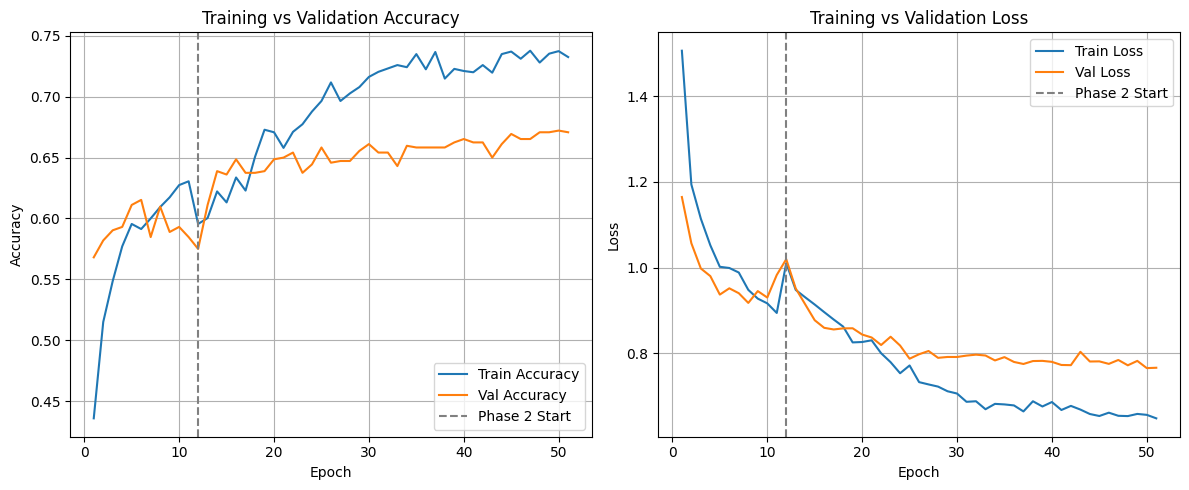

Plot saved to: /content/drive/MyDrive/training_accuracy.png

TRAINING COMPLETE
Classes        : ['child', 'infant', 'middle_age', 'senior', 'teen', 'young_adult']
Phase 1 Acc    : 61.53%
Final Acc      : 67.22%
Model saved to : /content/drive/MyDrive/model_age_demo.keras
Plot saved to  : /content/drive/MyDrive/training_accuracy.png

Next: Download model_age_demo.keras and run demo.py locally.


In [1]:
# ============================================================
#  Age Classification - Training Script
#  Run this in Google Colab with a T4 GPU
#  Austin Steffes - dotCon Demo
# ============================================================

# ── STEP 1: Mount Google Drive ───────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── STEP 2: Imports ──────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
)
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# ── STEP 3: Config ───────────────────────────────────────────
DATASET_DIR  = "/content/drive/MyDrive/dotCon/A4_dataset_ALL"
MODEL_PATH   = "/content/drive/MyDrive/model_age_demo.keras"
PLOT_PATH    = "/content/drive/MyDrive/training_accuracy.png"

IMAGE_SIZE   = (224, 224)   # EfficientNetV2B0 native pretraining resolution
BATCH_SIZE   = 32
SEED         = 42

# 600 per class was our best-performing data volume (70.14% run)
# 800 added noise from lower-quality source folders — reverted
TARGET_PER_CLASS = 600

# ── CLASS CONFIG (6 coarse brackets) ─────────────────────────
#
#   infant      :  0–3    very distinct — no facial structure yet
#   child       :  4–12   rounded features, no adult proportions
#   teen        : 13–19   adolescent features, some acne/asymmetry
#   young_adult : 20–35   full adult structure, minimal aging signs
#   middle_age  : 36–55   visible wrinkles, changed skin texture
#   senior      : 56–110  pronounced aging, grey hair, deeper lines
#
CLASS_CONFIG = [
    {
        "label":   "infant",
        "sources": ["001", "002", "003"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "child",
        "sources": ["004", "005", "006", "007", "008", "009", "010", "011", "012"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "teen",
        "sources": ["013", "014", "015", "016", "017", "018", "019"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "young_adult",
        "sources": ["020", "021", "022", "023", "024", "025", "026", "027", "028", "029", "030", "031", "032", "033", "034", "035"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "middle_age",
        "sources": ["036", "037", "038", "039", "040", "041", "042", "043", "044", "045", "046", "047", "048", "049", "050", "051", "052", "053", "054", "055"],
        "cap":     TARGET_PER_CLASS,
    },
    {
        "label":   "senior",
        "sources": ["056", "057", "058", "059", "060", "061", "062", "063", "064", "065", "066", "067", "068", "069", "070",
                    "075", "080", "085", "090", "095", "100", "105", "110"],
        "cap":     TARGET_PER_CLASS,
    },
]

NUM_CLASSES = len(CLASS_CONFIG)

# ── STEP 4: Build Balanced Dataset ───────────────────────────
import shutil
import random

random.seed(SEED)

FILTERED_DIR = "/content/dataset_filtered"

if os.path.exists(FILTERED_DIR):
    shutil.rmtree(FILTERED_DIR)
os.makedirs(FILTERED_DIR)

print("\nBuilding balanced dataset...")
print(f"Target per class : {TARGET_PER_CLASS} images")
print("-" * 45)

total_images = 0
for cfg in CLASS_CONFIG:
    label   = cfg["label"]
    sources = cfg["sources"]
    cap     = cfg["cap"]

    dst = os.path.join(FILTERED_DIR, label)
    os.makedirs(dst, exist_ok=True)

    # Collect all valid images from all source folders
    all_files = []
    for src_folder in sources:
        src_path = os.path.join(DATASET_DIR, src_folder)
        if os.path.exists(src_path):
            files = [
                os.path.join(src_path, f)
                for f in os.listdir(src_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            all_files.extend(files)
        # Silently skip missing folders (sparse dataset has gaps at high ages)

    # Shuffle and cap
    random.shuffle(all_files)
    selected = all_files[:cap] if cap else all_files

    # Copy into filtered dir, rename to avoid collisions across source folders
    for i, src_file in enumerate(selected):
        ext = os.path.splitext(src_file)[1]
        dst_file = os.path.join(dst, f"{label}_{i:04d}{ext}")
        shutil.copy2(src_file, dst_file)

    count = len(selected)
    total_images += count
    src_str = f"{sources[0]}–{sources[-1]}"
    print(f"  Class {label:<14} | folders: {src_str:<10} | {count:>3} images")

print("-" * 45)
print(f"  TOTAL          | {total_images} images across {NUM_CLASSES} classes")
print("\nDataset ready.")

# ── STEP 5: Data Augmentation ────────────────────────────────
# Conservative augmentation — stronger settings hurt training signal at this dataset size
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="augmentation")

# ── STEP 6: Load Data ────────────────────────────────────────
print("\nLoading dataset...")

common_args = dict(
    directory=FILTERED_DIR,
    validation_split=0.2,
    label_mode="categorical",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

training_set = image_dataset_from_directory(subset="training",   **common_args)
test_set     = image_dataset_from_directory(subset="validation", **common_args)

class_names = training_set.class_names
print(f"\nClasses ({len(class_names)}): {class_names}")
print(f"Training batches : {len(training_set)}")
print(f"Validation batches: {len(test_set)}")

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
training_set = training_set.prefetch(buffer_size=AUTOTUNE)
test_set     = test_set.prefetch(buffer_size=AUTOTUNE)

# ── STEP 7: Build Model ──────────────────────────────────────
print("\nBuilding model...")

base_model = EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3)
)

# Phase 1: Freeze entire base model
for layer in base_model.layers:
    layer.trainable = False

# Build inputs with augmentation baked into the model graph (runs on GPU)
inputs = tf.keras.Input(shape=(*IMAGE_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.4)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
output_layer = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=inputs, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"\nTotal params     : {model.count_params():,}")
print(f"Trainable params : {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

# ── STEP 8: Callbacks ────────────────────────────────────────
callbacks_phase1 = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# ── STEP 9: Phase 1 Training - Frozen Base ───────────────────
print("\n" + "="*50)
print("PHASE 1: Training top layers (base frozen)")
print("="*50)

history1 = model.fit(
    training_set,
    epochs=30,
    validation_data=test_set,
    callbacks=callbacks_phase1,
    verbose=2
)

score1 = model.evaluate(test_set, verbose=2)
print(f"\nPhase 1 - Val Accuracy: {round(score1[1] * 100, 2)}%")

# ── STEP 10: Phase 2 - Fine-Tuning ───────────────────────────
print("\n" + "="*50)
print("PHASE 2: Fine-tuning (unfreezing top base layers)")
print("="*50)

# Unfreeze top 30 layers — Phase 2 is now stable so give it more capacity
for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Trainable params after unfreeze: {sum([tf.size(w).numpy() for w in model.trainable_weights]):,}")

callbacks_phase2 = [
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_accuracy",
        patience=10,              # More room to recover after LR drops
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,               # Smaller LR steps — don't kill momentum
        patience=6,               # Wait longer before cutting LR
        verbose=1
    )
]

history2 = model.fit(
    training_set,
    epochs=40,                    # More runway — model was still climbing at ep 23
    validation_data=test_set,
    callbacks=callbacks_phase2,
    verbose=2
)

score2 = model.evaluate(test_set, verbose=2)
print(f"\nPhase 2 - Final Val Accuracy: {round(score2[1] * 100, 2)}%")

# ── STEP 11: Save Final Model ────────────────────────────────
model.save(MODEL_PATH)
print(f"\nModel saved to: {MODEL_PATH}")

# ── STEP 12: Plot Training History ───────────────────────────
acc1  = history1.history["accuracy"]
acc2  = history2.history["accuracy"]
val1  = history1.history["val_accuracy"]
val2  = history2.history["val_accuracy"]

all_acc     = acc1 + acc2
all_val_acc = val1 + val2
epochs_range = range(1, len(all_acc) + 1)
phase2_start = len(acc1) + 1

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, all_acc,     label="Train Accuracy")
plt.plot(epochs_range, all_val_acc, label="Val Accuracy")
plt.axvline(x=phase2_start, color="gray", linestyle="--", label="Phase 2 Start")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

loss1     = history1.history["loss"]
loss2     = history2.history["loss"]
val_loss1 = history1.history["val_loss"]
val_loss2 = history2.history["val_loss"]

all_loss     = loss1 + loss2
all_val_loss = val_loss1 + val_loss2

plt.subplot(1, 2, 2)
plt.plot(epochs_range, all_loss,     label="Train Loss")
plt.plot(epochs_range, all_val_loss, label="Val Loss")
plt.axvline(x=phase2_start, color="gray", linestyle="--", label="Phase 2 Start")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(PLOT_PATH)
plt.show()
print(f"Plot saved to: {PLOT_PATH}")

# ── STEP 13: Summary ─────────────────────────────────────────
print("\n" + "="*50)
print("TRAINING COMPLETE")
print("="*50)
print(f"Classes        : {class_names}")
print(f"Phase 1 Acc    : {round(score1[1] * 100, 2)}%")
print(f"Final Acc      : {round(score2[1] * 100, 2)}%")
print(f"Model saved to : {MODEL_PATH}")
print(f"Plot saved to  : {PLOT_PATH}")
print("\nNext: Download model_age_demo.keras and run demo.py locally.")